# tests

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
# channels=3
path=r'c:\Users\juvad3723\.1\--Projects\GitHub\north_sea_dl-mapping\data\s1\eval\ssl\2018_01_03_174157_00876.tif'


def load_img(path, channels):
    with open(path, "rb") as f:
        img = Image.open(f)
        if channels==3:
            return img.convert("RGB")
        elif channels==1:
            return img.convert("I;16")

img = load_img(path, 1)

print(np.min(img), np.max(img), np.mean(img))
plt.imshow(img)

I;16


TypeError: unsupported operand type(s) for /: 'NoneType' and 'int'

# Dinov2

## Vits16_224 example

In [ ]:
#Dinov2
# This example requires the following dependencies to be installed:
# pip install lightly

# Note: The model and training settings do not follow the reference settings
# from the paper. The settings are chosen such that the example can easily be
# run on a small dataset with a single GPU.

import copy
from functools import partial

import torch
import torchvision
from timm.models.vision_transformer import vit_small_patch16_224
from torch import Tensor
from torch.nn import Module
from torch.optim import AdamW

from lightly.loss import DINOLoss, IBOTPatchLoss, KoLeoLoss
from lightly.models.modules import DINOv2ProjectionHead, MaskedVisionTransformerTIMM
from lightly.models.utils import (
    random_block_mask,
    update_drop_path_rate,
    update_momentum,
)
from lightly.transforms.dino_transform import DINOTransform
from lightly.utils.scheduler import cosine_schedule, linear_warmup_schedule



def freeze_eval_module(module: Module) -> None:
    """Freeze the parameters of a module."""
    for param in module.parameters():
        param.requires_grad = False
    module.eval()



class DINOv2Head(Module):
    def __init__(
        self, dino_head: DINOv2ProjectionHead, ibot_head: DINOv2ProjectionHead
    ) -> None:
        super().__init__()
        self.dino_head = dino_head
        self.ibot_head = ibot_head



class DINOv2(Module):
    def __init__(
        self,
        ibot_separate_head: bool = False,
    ) -> None:
        super().__init__()

        # Backbones
        vit_teacher = vit_small_patch16_224(
            pos_embed="learn",
            dynamic_img_size=True,
            init_values=1e-5,
            in_chans=1
        )
        self.teacher_backbone = MaskedVisionTransformerTIMM(
            vit=vit_teacher,
            antialias=False,
            pos_embed_initialization="skip",
        )
        self.student_backbone = copy.deepcopy(self.teacher_backbone)
        update_drop_path_rate(
            self.student_backbone.vit,
            drop_path_rate=0.1,  # we recommend using smaller rates like 0.1 for vit-s-14
            mode="uniform",
        )

        freeze_eval_module(self.teacher_backbone)

        # Heads
        dino_head = partial(
            DINOv2ProjectionHead,
            input_dim=384,
        )

        teacher_dino_head = dino_head()
        student_dino_head = dino_head()

        ibot_head = partial(
            DINOv2ProjectionHead,
            input_dim=384,
        )

        if ibot_separate_head:
            teacher_ibot_head = ibot_head()
            student_ibot_head = ibot_head()
        else:
            teacher_ibot_head = teacher_dino_head
            student_ibot_head = student_dino_head

        self.teacher_head = DINOv2Head(
            dino_head=teacher_dino_head,
            ibot_head=teacher_ibot_head,
        )
        self.student_head = DINOv2Head(
            dino_head=student_dino_head,
            ibot_head=student_ibot_head,
        )

        freeze_eval_module(self.teacher_head)

    def forward(self, x: Tensor) -> Tensor:
        return self.teacher_backbone(x)

    def forward_teacher(self, x: Tensor) -> tuple[Tensor, Tensor]:
        features = self.teacher_backbone.encode(x)
        cls_tokens = features[:, 0]
        return cls_tokens, features

    def forward_student(
        self, x: Tensor, mask: Tensor | None
    ) -> tuple[Tensor, Tensor | None]:
        features = self.student_backbone.encode(x, mask=mask)
        cls_tokens = features[:, 0]
        masked_features = None if mask is None else features[mask]
        return cls_tokens, masked_features


model = DINOv2()


transform = DINOTransform(
    global_crop_size=224,
    local_crop_size=96,
    global_crop_scale=(0.5, 1.0),
    local_crop_scale=(0.05, 0.32),
    n_local_views=8,
    normalize={'mean':[0], 'std': [1]}
)
# transform = DINOTransform(
#     global_crop_size=256,
#     local_crop_size=128,
#     global_crop_scale=(0.4, 1.0),
#     local_crop_scale=(0.05, 0.3),
#     n_local_views=6,
# )


# We ignore object detection annotations by setting target_transform to return 0.
def target_transform(t):
    return 0


device = "cuda" if torch.cuda.is_available() else "mps"
model.to(device)


from lightly.data import LightlyDataset
# Or create a dataset from a folder containing images or videos.
TILES_FOLDER_PATH = r'c:\Users\juvad3723\.1\--Projects\GitHub\north_sea_dl-mapping\data\s1\eval\ssl'

dataset = LightlyDataset(TILES_FOLDER_PATH, transform=transform)


dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    drop_last=True,
    num_workers=4,
)


# Create the loss functions.
dino_criterion = DINOLoss()
ibot_criterion = IBOTPatchLoss()
koleo_criterion = KoLeoLoss()


# Move loss to correct device because it also contains parameters.
dino_criterion = dino_criterion.to(device)
ibot_criterion = ibot_criterion.to(device)
koleo_criterion = koleo_criterion.to(device)


optimizer = AdamW(model.parameters(), lr=1e-3)


epochs = 20
num_batches = len(dataloader)
total_steps = epochs * num_batches


# print("Starting Training")
# for epoch in range(epochs):
#     total_loss = 0
#     for batch_idx, batch in enumerate(dataloader):
#         views = batch[0]
#         views = [view.to(device) for view in views]
#         global_views = torch.cat(views[:2])
#         local_views = torch.cat(views[2:])

#         # Masking
#         B = len(global_views)
#         sequence_length = model.teacher_backbone.sequence_length
#         mask = global_views.new_zeros((B, sequence_length), dtype=torch.bool)

#         # Mask patches except class token.
#         H, W = model.teacher_backbone.vit.patch_embed.grid_size
#         assert H * W == sequence_length - 1, (
#             f"Unexpected grid size: {H}x{W}, sequence_length {sequence_length}"
#         )
#         block_mask = random_block_mask(size=(B, H, W), device=mask.device)
#         mask[:, 1:] = block_mask.flatten(start_dim=1)

#         # Teacher forward
#         with torch.no_grad():
#             teacher_cls_token, teacher_features = model.forward_teacher(global_views)
#             teacher_cls_out = model.teacher_head.dino_head.forward(teacher_cls_token)
#             teacher_masked_out = model.teacher_head.ibot_head.forward(
#                 teacher_features[mask]
#             )

#         # Student forward
#         (
#             student_global_cls_token,
#             student_global_masked_features,
#         ) = model.forward_student(global_views, mask=mask)
#         student_global_cls_out = model.student_head.dino_head.forward(
#             student_global_cls_token
#         )
#         student_global_masked_out = model.student_head.ibot_head.forward(
#             student_global_masked_features
#         )
#         student_local_cls_token, _ = model.forward_student(local_views, mask=None)
#         student_local_cls_out = model.student_head.dino_head.forward(
#             student_local_cls_token
#         )
#         student_cls_out = torch.cat([student_global_cls_out, student_local_cls_out])

#         # Calculate current global step based on epoch and batch index.
#         global_step = epoch * num_batches + batch_idx

#         # Calculate the loss.
#         teacher_temp = linear_warmup_schedule(
#             step=global_step,
#             warmup_steps=int(30 / epochs * total_steps),
#             start_value=0.04,
#             end_value=0.07,
#         )
#         dino_loss = dino_criterion(
#             teacher_out=teacher_cls_out.chunk(2),
#             student_out=student_cls_out.chunk(len(views)),
#             teacher_temp=teacher_temp,
#         )
#         ibot_loss = ibot_criterion(
#             teacher_out=teacher_masked_out,
#             student_out=student_global_masked_out,
#             mask=block_mask,
#             teacher_temp=teacher_temp,
#         )
#         koleo_loss = 0.1 * sum(
#             koleo_criterion(t) for t in student_global_cls_token.chunk(2)
#         )
#         loss = dino_loss + ibot_loss + koleo_loss

#         total_loss += loss.detach()
#         loss.backward()

#         # Optionally zero out the learning rate of the last layer.
#         if epoch < 1:
#             for param_group in optimizer.param_groups:
#                 if "last_layer" in param_group:
#                     param_group["lr"] = 0.0

#         # Apply weight decay schedule.
#         weight_decay = cosine_schedule(
#             step=global_step,
#             max_steps=total_steps,
#             start_value=0.04,
#             end_value=0.4,
#         )

#         # Update weight decay directly for all parameter groups.
#         for group in optimizer.param_groups:
#             if group["weight_decay"] != 0.0:
#                 group["weight_decay"] = weight_decay

#         optimizer.step()
#         optimizer.zero_grad()

#         # Momentum update teacher.
#         momentum = cosine_schedule(
#             step=global_step,
#             max_steps=total_steps,
#             start_value=0.992,
#             end_value=1.0,
#         )
#         update_momentum(model.student_backbone, model.teacher_backbone, m=momentum)
#         update_momentum(model.student_head, model.teacher_head, m=momentum)

#     avg_loss = total_loss / len(dataloader)
#     print(f"epoch: {epoch:>02}, loss: {avg_loss:.5f}")

c:\Users\juvad3723\.1\--Projects\GitHub\lightly_sar\.venv\Lib\site-packages\torch\nn\utils\weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


## Dinov2 vitb8-224

In [ ]:
#Dinov2
# This example requires the following dependencies to be installed:
# pip install lightly

# Note: The model and training settings do not follow the reference settings
# from the paper. The settings are chosen such that the example can easily be
# run on a small dataset with a single GPU.

import copy
from functools import partial

import torch
import torchvision
from timm.models.vision_transformer import vit_base_patch8_224
from torch import Tensor
from torch.nn import Module
from torch.optim import AdamW

from lightly.loss import DINOLoss, IBOTPatchLoss, KoLeoLoss
from lightly.models.modules import DINOv2ProjectionHead, MaskedVisionTransformerTIMM
from lightly.models.utils import (
    random_block_mask,
    update_drop_path_rate,
    update_momentum,
)
from lightly.transforms.dino_transform import DINOTransform
from lightly.utils.scheduler import cosine_schedule, linear_warmup_schedule



def freeze_eval_module(module: Module) -> None:
    """Freeze the parameters of a module."""
    for param in module.parameters():
        param.requires_grad = False
    module.eval()



class DINOv2Head(Module):
    def __init__(
        self, dino_head: DINOv2ProjectionHead, ibot_head: DINOv2ProjectionHead
    ) -> None:
        super().__init__()
        self.dino_head = dino_head
        self.ibot_head = ibot_head



class DINOv2(Module):
    def __init__(
        self,
        ibot_separate_head: bool = False,
    ) -> None:
        super().__init__()

        # Backbones
        vit_teacher = vit_base_patch8_224(
            pos_embed="learn",
            dynamic_img_size=True,
            init_values=1e-5,
            in_chans=1
        )
        self.teacher_backbone = MaskedVisionTransformerTIMM(
            vit=vit_teacher,
            antialias=False,
            pos_embed_initialization="skip",
        )
        self.student_backbone = copy.deepcopy(self.teacher_backbone)
        update_drop_path_rate(
            self.student_backbone.vit,
            drop_path_rate=0.1,  # we recommend using smaller rates like 0.1 for vit-s-14
            mode="uniform",
        )

        freeze_eval_module(self.teacher_backbone)

        # Heads
        dino_head = partial(
            DINOv2ProjectionHead,
            input_dim=384,
        )

        teacher_dino_head = dino_head()
        student_dino_head = dino_head()

        ibot_head = partial(
            DINOv2ProjectionHead,
            input_dim=384,
        )

        if ibot_separate_head:
            teacher_ibot_head = ibot_head()
            student_ibot_head = ibot_head()
        else:
            teacher_ibot_head = teacher_dino_head
            student_ibot_head = student_dino_head

        self.teacher_head = DINOv2Head(
            dino_head=teacher_dino_head,
            ibot_head=teacher_ibot_head,
        )
        self.student_head = DINOv2Head(
            dino_head=student_dino_head,
            ibot_head=student_ibot_head,
        )

        freeze_eval_module(self.teacher_head)

    def forward(self, x: Tensor) -> Tensor:
        return self.teacher_backbone(x)

    def forward_teacher(self, x: Tensor) -> tuple[Tensor, Tensor]:
        features = self.teacher_backbone.encode(x)
        cls_tokens = features[:, 0]
        return cls_tokens, features

    def forward_student(
        self, x: Tensor, mask: Tensor | None
    ) -> tuple[Tensor, Tensor | None]:
        features = self.student_backbone.encode(x, mask=mask)
        cls_tokens = features[:, 0]
        masked_features = None if mask is None else features[mask]
        return cls_tokens, masked_features


model = DINOv2()


transform = DINOTransform(
    global_crop_size=224,
    local_crop_size=96,
    global_crop_scale=(0.5, 1.0),
    local_crop_scale=(0.05, 0.32),
    n_local_views=8,
    normalize=None
)


# We ignore object detection annotations by setting target_transform to return 0.
def target_transform(t):
    return 0


device = "cuda" if torch.cuda.is_available() else "mps"
model.to(device)


from lightly.data import LightlyDataset
# Or create a dataset from a folder containing images or videos.
TILES_FOLDER_PATH = r'c:\Users\juvad3723\.1\--Projects\GitHub\north_sea_dl-mapping\data\s1\eval\ssl'

dataset = LightlyDataset(TILES_FOLDER_PATH, transform=transform)


dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    drop_last=True,
    num_workers=4,
)


# Create the loss functions.
dino_criterion = DINOLoss()
ibot_criterion = IBOTPatchLoss()
koleo_criterion = KoLeoLoss()


# Move loss to correct device because it also contains parameters.
dino_criterion = dino_criterion.to(device)
ibot_criterion = ibot_criterion.to(device)
koleo_criterion = koleo_criterion.to(device)


optimizer = AdamW(model.parameters(), lr=1e-3)


epochs = 20
num_batches = len(dataloader)
total_steps = epochs * num_batches


# print("Starting Training")
# for epoch in range(epochs):
#     total_loss = 0
#     for batch_idx, batch in enumerate(dataloader):
#         views = batch[0]
#         views = [view.to(device) for view in views]
#         global_views = torch.cat(views[:2])
#         local_views = torch.cat(views[2:])

#         # Masking
#         B = len(global_views)
#         sequence_length = model.teacher_backbone.sequence_length
#         mask = global_views.new_zeros((B, sequence_length), dtype=torch.bool)

#         # Mask patches except class token.
#         H, W = model.teacher_backbone.vit.patch_embed.grid_size
#         assert H * W == sequence_length - 1, (
#             f"Unexpected grid size: {H}x{W}, sequence_length {sequence_length}"
#         )
#         block_mask = random_block_mask(size=(B, H, W), device=mask.device)
#         mask[:, 1:] = block_mask.flatten(start_dim=1)

#         # Teacher forward
#         with torch.no_grad():
#             teacher_cls_token, teacher_features = model.forward_teacher(global_views)
#             teacher_cls_out = model.teacher_head.dino_head.forward(teacher_cls_token)
#             teacher_masked_out = model.teacher_head.ibot_head.forward(
#                 teacher_features[mask]
#             )

#         # Student forward
#         (
#             student_global_cls_token,
#             student_global_masked_features,
#         ) = model.forward_student(global_views, mask=mask)
#         student_global_cls_out = model.student_head.dino_head.forward(
#             student_global_cls_token
#         )
#         student_global_masked_out = model.student_head.ibot_head.forward(
#             student_global_masked_features
#         )
#         student_local_cls_token, _ = model.forward_student(local_views, mask=None)
#         student_local_cls_out = model.student_head.dino_head.forward(
#             student_local_cls_token
#         )
#         student_cls_out = torch.cat([student_global_cls_out, student_local_cls_out])

#         # Calculate current global step based on epoch and batch index.
#         global_step = epoch * num_batches + batch_idx

#         # Calculate the loss.
#         teacher_temp = linear_warmup_schedule(
#             step=global_step,
#             warmup_steps=int(30 / epochs * total_steps),
#             start_value=0.04,
#             end_value=0.07,
#         )
#         dino_loss = dino_criterion(
#             teacher_out=teacher_cls_out.chunk(2),
#             student_out=student_cls_out.chunk(len(views)),
#             teacher_temp=teacher_temp,
#         )
#         ibot_loss = ibot_criterion(
#             teacher_out=teacher_masked_out,
#             student_out=student_global_masked_out,
#             mask=block_mask,
#             teacher_temp=teacher_temp,
#         )
#         koleo_loss = 0.1 * sum(
#             koleo_criterion(t) for t in student_global_cls_token.chunk(2)
#         )
#         loss = dino_loss + ibot_loss + koleo_loss

#         total_loss += loss.detach()
#         loss.backward()

#         # Optionally zero out the learning rate of the last layer.
#         if epoch < 1:
#             for param_group in optimizer.param_groups:
#                 if "last_layer" in param_group:
#                     param_group["lr"] = 0.0

#         # Apply weight decay schedule.
#         weight_decay = cosine_schedule(
#             step=global_step,
#             max_steps=total_steps,
#             start_value=0.04,
#             end_value=0.4,
#         )

#         # Update weight decay directly for all parameter groups.
#         for group in optimizer.param_groups:
#             if group["weight_decay"] != 0.0:
#                 group["weight_decay"] = weight_decay

#         optimizer.step()
#         optimizer.zero_grad()

#         # Momentum update teacher.
#         momentum = cosine_schedule(
#             step=global_step,
#             max_steps=total_steps,
#             start_value=0.992,
#             end_value=1.0,
#         )
#         update_momentum(model.student_backbone, model.teacher_backbone, m=momentum)
#         update_momentum(model.student_head, model.teacher_head, m=momentum)

#     avg_loss = total_loss / len(dataloader)
#     print(f"epoch: {epoch:>02}, loss: {avg_loss:.5f}")

In [ ]:
print(model.teacher_backbone.vit)

AttributeError: 'VisionTransformer' object has no attribute 'window_imgs_semantic'

In [6]:
import os
os.chdir(r'c:\Users\juvad3723\.1\--Projects\GitHub\clean_repo')
torch.save(
    model.teacher_backbone.vit.state_dict(),
    "models/ssl/dinov2_vit_small_patch16_224_testrunOlivia.pth"
)

In [18]:
import torch

pth_load = torch.load("models/ssl/dinov2_vit_small_patch16_224_testrunOlivia.pth")
print(pth_load.keys())

odict_keys(['cls_token', 'pos_embed', 'patch_embed.proj.weight', 'patch_embed.proj.bias', 'blocks.0.norm1.weight', 'blocks.0.norm1.bias', 'blocks.0.attn.qkv.weight', 'blocks.0.attn.qkv.bias', 'blocks.0.attn.proj.weight', 'blocks.0.attn.proj.bias', 'blocks.0.ls1.gamma', 'blocks.0.norm2.weight', 'blocks.0.norm2.bias', 'blocks.0.mlp.fc1.weight', 'blocks.0.mlp.fc1.bias', 'blocks.0.mlp.fc2.weight', 'blocks.0.mlp.fc2.bias', 'blocks.0.ls2.gamma', 'blocks.1.norm1.weight', 'blocks.1.norm1.bias', 'blocks.1.attn.qkv.weight', 'blocks.1.attn.qkv.bias', 'blocks.1.attn.proj.weight', 'blocks.1.attn.proj.bias', 'blocks.1.ls1.gamma', 'blocks.1.norm2.weight', 'blocks.1.norm2.bias', 'blocks.1.mlp.fc1.weight', 'blocks.1.mlp.fc1.bias', 'blocks.1.mlp.fc2.weight', 'blocks.1.mlp.fc2.bias', 'blocks.1.ls2.gamma', 'blocks.2.norm1.weight', 'blocks.2.norm1.bias', 'blocks.2.attn.qkv.weight', 'blocks.2.attn.qkv.bias', 'blocks.2.attn.proj.weight', 'blocks.2.attn.proj.bias', 'blocks.2.ls1.gamma', 'blocks.2.norm2.weight

In [10]:
from timm.models.vision_transformer import vit_small_patch16_224, vit_base_patch14_dinov2

model = vit_base_patch14_dinov2(
            pos_embed="learn",
            dynamic_img_size=True,
            init_values=1e-5,
            in_chans=3
        )

model.patch_embed.grid_size

(37, 37)

In [ ]:
import torch
import timm
from timm.models.vision_transformer import vit_small_patch16_224, vit_base_patch14_dinov2

# Create the same architecture
model = vit_small_patch16_224(
            pos_embed="learn",
            dynamic_img_size=True,
            init_values=1e-5,
            in_chans=3
        )

# Load weights
state_dict = torch.load("models/ssl/dinov2_vit_small_patch16_224_testrunOlivia.pth")

state_dict.pop("head.weight", None)
state_dict.pop("head.bias", None)

model.load_state_dict(state_dict, strict=False)
model.eval()

FileNotFoundError: [Errno 2] No such file or directory: 'models/ssl/dinov2_vit_small_patch16_224_testrunOlivia.pth'

In [41]:
missing, unexpected = model.load_state_dict(
    state_dict,
    strict=False
)

print("Missing:", missing)
print("Unexpected:", unexpected)

Missing: []
Unexpected: ['blocks.0.ls1.gamma', 'blocks.0.ls2.gamma', 'blocks.1.ls1.gamma', 'blocks.1.ls2.gamma', 'blocks.2.ls1.gamma', 'blocks.2.ls2.gamma', 'blocks.3.ls1.gamma', 'blocks.3.ls2.gamma', 'blocks.4.ls1.gamma', 'blocks.4.ls2.gamma', 'blocks.5.ls1.gamma', 'blocks.5.ls2.gamma', 'blocks.6.ls1.gamma', 'blocks.6.ls2.gamma', 'blocks.7.ls1.gamma', 'blocks.7.ls2.gamma', 'blocks.8.ls1.gamma', 'blocks.8.ls2.gamma', 'blocks.9.ls1.gamma', 'blocks.9.ls2.gamma', 'blocks.10.ls1.gamma', 'blocks.10.ls2.gamma', 'blocks.11.ls1.gamma', 'blocks.11.ls2.gamma']


# plot embeddings

In [42]:
from glob import glob
import random
img_list = glob(r'c:\Users\juvad3723\.1\--Projects\GitHub\north_sea_dl-mapping\data\s1\eval\ssl\*.tif')
random.shuffle(img_list)

In [46]:
IDX = 0

In [1]:
import torch
from PIL import Image
from torchvision import transforms

model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

img = Image.open(img_list[IDX]).convert("RGB")
x = transform(img).unsqueeze(0)
print(x.shape)
with torch.no_grad():
    feats = model.forward_features(x)

print(type(feats))
print(feats.shape)

import matplotlib.pyplot as plt

# Remove CLS token
patch_tokens = feats[:, 1:, :]  # [1, 196, 384]

# Convert to 14x14 patch grid
feature_map = patch_tokens.reshape(1, 14, 14, 384)

# Mean activation across channels
feat_vis = feature_map[0].mean(dim=-1).cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Original image (PIL image)
ax[0].imshow(img, cmap="gray")
ax[0].set_title("Input")
ax[0].axis("off")

# Feature map
im = ax[1].imshow(feat_vis, cmap="viridis")
ax[1].set_title("Mean ViT Features")
ax[1].axis("off")

plt.colorbar(im, ax=ax[1])
plt.tight_layout()
plt.show()

IDX +=1

NameError: name 'model' is not defined

# Train eomt

In [ ]:
import lightly_train

if __name__ == "__main__":
    lightly_train.train_semantic_segmentation(
        out="out/my_experiment",
        model="dinov2/vitl14-eomt", 
        data={
            "train": {
                "images": "data/pytorch_samples/512_20/northsea/train/seep/images",   # Path to training images
                "masks": 'data/pytorch_samples/512_20/northsea/train/seep/masks',     # Path to training masks
            },
            "val": {
                "images": "data/pytorch_samples/512_20/northsea/val/seep/labels",     # Path to validation images
                "masks": 'data/pytorch_samples/512_20/northsea/val/seep/masks',       # Path to validation masks
            },
            "classes": {                                # Classes in the dataset                    
                0: "background",
                1: "oil",
            },
        },
        transform_args={
            "image_size": [
                224,
                224
            ],
            "normalize": {
                "mean": [
                    0.485,
                    0.456,
                    0.406
                ],
                "std": [
                    0.229,
                    0.224,
                    0.225
                ]
            },
            "num_channels": 3,
            }
    )

# use eomt

In [25]:
import lightly_train
import os
os.chdir(r'c:\Users\juvad3723\.1\--Projects\GitHub\clean_repo')
print(lightly_train.__version__)
model_path = "models/ssl-eomt_testrun/checkpoints/best.ckpt"

# Load model
model = lightly_train.load_model_from_checkpoint(model_path, device="cuda:0")
model.eval()
model.to("cuda:0")
IDX = 0

0.17.0


In [17]:
IDX-=2

In [1]:
print('a')

a


In [21]:
import os
os.chdir(r'c:\Users\juvad3723\.1\--Projects\GitHub\clean_repo')
import rasterio
from glob import glob
import random

IDX = -1
IDX+=1

img_list = glob(
    "data/training_samples/pytorch_512_20_n_curated/test/images/*.tif"
)
random.seed(0)
random.shuffle(img_list)

img_path = img_list[IDX]
# import albumentations as A
# from albumentations.pytorch import ToTensorV2

# transform = A.Compose([
#     A.SmallestMaxSize(
#         max_size=518,
#         p=1.0,
#     ),
#     A.Normalize(
#         mean=(0.485, 0.456, 0.406),
#         std=(0.229, 0.224, 0.225),
#     ),
#     ToTensorV2(),
# ])
from torchvision import transforms
from torchvision.transforms import InterpolationMode
import torch

import numpy as np
import torch
from PIL import Image
from torchvision import transforms
from torchvision.transforms import InterpolationMode


transform = transforms.Compose([
    transforms.Resize(
        518,
        interpolation=InterpolationMode.BILINEAR,
        antialias=True,
    ),
    transforms.Normalize(
        mean=(0.485,),
        std=(0.225,),
    ),
])


with Image.open(img_path) as image:
    # I;16 -> float32 in [0, 1]
    arr = np.asarray(image, dtype=np.float32) / 65535.0

    # H,W -> C,H,W
    tensor = torch.from_numpy(arr).unsqueeze(0)

    # C,H,W
    tensor = transform(tensor)

print(tensor.shape)

print(image.size)
# print(image.min())
# print(image.max())
print(tensor.shape)
print(tensor.min())
print(tensor.max())

torch.Size([1, 518, 518])
(512, 512)
torch.Size([1, 518, 518])
tensor(-2.1523)
tensor(-2.1418)


data/training_samples/pytorch_512_20_n_curated/test/images\2016_11_03_062919_00351.tif
tensor(0, device='cuda:0')


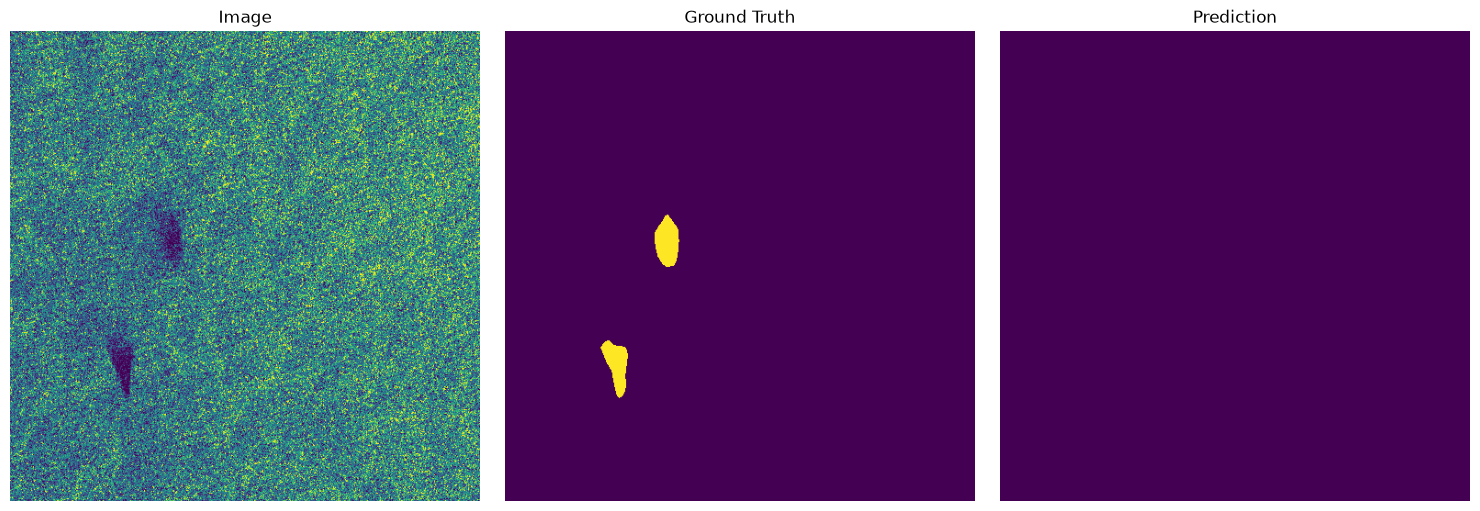

In [30]:
import os
os.chdir(r'c:\Users\juvad3723\.1\--Projects\GitHub\clean_repo')
from glob import glob

# import lightly_train
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import torch
import random
from my_code.utils.transforms import imagenet_transform, dinov2_test_transform

# IDX = 0
IDX+=1

img_list = glob(
    "data/training_samples/pytorch_512_20_n_curated/test/images/*.tif"
)
random.seed(0)
random.shuffle(img_list)

img_path = img_list[IDX]

print(img_path)
mask_path = img_path.replace("images", "labels")

# # transform = imagenet_transform(518)
# transform = dinov2_test_transform(518)

# Load image
with rasterio.open(img_path) as src:
    image = src.read()
#     # tensor = transform(image)
#     # print(tensor.shape)

vmin = np.percentile(image, 2)
vmax = np.percentile(image, 98)


# Load ground-truth mask
assert os.path.isfile(mask_path)

with rasterio.open(mask_path) as src:
    mask = src.read(1)

mask = torch.from_numpy(mask).short()

# Prediction
with torch.no_grad():
    # output = model.predict(tensor)  # (H, W)
    output = model.predict(img_path)
print(output.max())

# # Convert prediction to numpy
prediction = output.detach().cpu().numpy()

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# Convert CHW -> HWC for plotting
image = np.moveaxis(image, 0, -1)
axes[0].imshow(image, vmin=vmin, vmax=vmax)
axes[0].set_title("Image")
axes[0].axis("off")

axes[1].imshow(mask.numpy())
axes[1].set_title("Ground Truth")
axes[1].axis("off")

axes[2].imshow(prediction)
axes[2].set_title("Prediction")
axes[2].axis("off")

plt.tight_layout()
plt.show()